# References
- http://karpathy.github.io/2015/05/21/rnn-effectiveness/
- http://colah.github.io/posts/2015-08-Understanding-LSTMs/
- https://towardsdatascience.com/illustrated-guide-to-lstms-and-gru-s-a-step-by-step-explanation-44e9eb85bf21

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# Setup Data

In [ ]:
class DataHandler:
    def __init__(self, string):
        self.string = string
        
        characters = np.sort(list(set(string)))
        self.num_characters = len(characters)
        
        self.char_to_idx = { ch : i for i, ch in enumerate(characters) }
        self.idx_to_char = { i : ch for ch, i in self.char_to_idx.items() }
        
        self._process()
        
    def _process(self):
        data_torch = torch.tensor([self.make_onehot(ele).data.numpy() for ele in self.string])

        self.X = data_torch[:-1].float()
        self.y = torch.argmax(data_torch[1:], dim=1).long()
        
    def make_onehot(self, char):
        return torch.eye(self.num_characters)[self.char_to_idx[char]].float()

In [ ]:
data = DataHandler("Hello, RNN!")

# Model

In [ ]:
class VanillaCell(nn.Module):
    def __init__(self, num_chars, num_hidden):
        super().__init__()
        
        self.num_chars = num_chars
        self.num_hidden = num_hidden
        
        # Network Parameters
        # Potential Input
        self.Wxh = nn.Parameter(torch.randn((num_chars, num_hidden)))
        self.Whh = nn.Parameter(torch.randn((num_hidden, num_hidden)))
        self.bh = nn.Parameter(torch.zeros((num_hidden)))
        
        # Hidden -> Output
        self.Why = nn.Parameter(torch.randn((num_hidden, num_chars)))
        self.by = nn.Parameter(torch.zeros((num_chars))) 
        
        # Activations
        self.tanh = nn.Tanh()
    
    def init(self):
        # Initialize hidden state to zero
        self.h = torch.zeros((self.num_hidden))
        
    def forward(self, x):
        self.h = self.tanh((x @ self.Wxh) + (self.h @ self.Whh + self.bh))
        y_output = self.h @ self.Why + self.by
        return y_output

In [ ]:
class LSTMCell(nn.Module):
    def __init__(self, num_chars, num_hidden):
        super().__init__()
        
        self.num_chars = num_chars
        self.num_hidden = num_hidden
        
        # Network Parameters
        # Potential Input
        self.Wxh = nn.Parameter(torch.randn((num_chars, num_hidden)))
        self.Whh = nn.Parameter(torch.randn((num_hidden, num_hidden)))
        self.bh = nn.Parameter(torch.zeros((num_hidden)))
        
        # Input gate parameters
        self.Wxh_i = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_i = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_i = nn.Parameter(torch.randn_like(self.bh))
        
        # Forget gate parameters
        self.Wxh_f = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_f = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_f = nn.Parameter(torch.randn_like(self.bh))
        
        # Output gate parameters
        self.Wxh_o = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_o = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_o = nn.Parameter(torch.randn_like(self.bh))
        
        # Hidden -> Output
        self.Why = nn.Parameter(torch.randn((num_hidden, num_chars)))
        self.by = nn.Parameter(torch.zeros((num_chars))) 
        
        # Activations
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
    
    def init(self):
        self.h = torch.zeros((self.num_hidden))  # Hidden state
        self.c = torch.zeros((self.num_hidden))  # Cell state
        
    def forward(self, x):
        potential_input = self.tanh((x @ self.Wxh) + (self.h @ self.Whh + self.bh))
        
        # Gate updates
        input_gate = self.sigmoid((x @ self.Wxh_i) + (self.h @ self.Whh_i + self.bh_i))
        forget_gate = self.sigmoid((x @ self.Wxh_f) + (self.h @ self.Whh_f + self.bh_f))
        output_gate = self.sigmoid((x @ self.Wxh_o) + (self.h @ self.Whh_o + self.bh_o))
        
        # Update c and h
        self.c = self.c * forget_gate + potential_input * input_gate
        self.h = output_gate * self.tanh(self.c)
        
        y_output = self.h @ self.Why + self.by
        
        return y_output

In [ ]:
class GRUCell(nn.Module):
    def __init__(self, num_chars, num_hidden):
        super().__init__()
        
        self.num_chars = num_chars
        self.num_hidden = num_hidden
        
        # Network Parameters
        # Potential Input
        self.Wxh = nn.Parameter(torch.randn((num_chars, num_hidden)))
        self.Whh = nn.Parameter(torch.randn((num_hidden, num_hidden)))
        self.bh = nn.Parameter(torch.zeros((num_hidden)))
        
        # Update gate parameters
        self.Wxh_u = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_u = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_u = nn.Parameter(torch.randn_like(self.bh))
        
        # Reset gate parameters
        self.Wxh_r = nn.Parameter(torch.randn_like(self.Wxh))
        self.Whh_r = nn.Parameter(torch.randn_like(self.Whh))
        self.bh_r = nn.Parameter(torch.randn_like(self.bh))
        
        # Hidden -> Output
        self.Why = nn.Parameter(torch.randn((num_hidden, num_chars)))
        self.by = nn.Parameter(torch.zeros((num_chars))) 
        
        # Activations
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
    
    def init(self):
        self.h = torch.zeros((self.num_hidden))  # Hidden state
        
    def forward(self, x):
        
        # Gate updates
        update_gate = self.sigmoid((x @ self.Wxh_u) + (self.h @ self.Whh_u + self.bh_u))
        reset_gate = self.sigmoid((x @ self.Wxh_r) + (self.h @ self.Whh_r + self.bh_r))
        
        potential_input = self.tanh((x @ self.Wxh) + (reset_gate @ self.Whh + self.bh))
        
        self.h = self.h * (1-update_gate) + (potential_input * update_gate)
        y_output = self.h @ self.Why + self.by
        
        return y_output

In [ ]:
class HelloRNN(nn.Module):
    cells = {
        "LSTM"    : LSTMCell,
        "GRU"     : GRUCell,
        "vanilla" : VanillaCell
    }
    
    def __init__(self, num_chars, num_hidden=10, cell_type='LSTM'):
        super().__init__()

        self.cell_type = cell_type
        print(f"Creating RNN with cell: {cell_type}")
        self.cell = HelloRNN.cells[cell_type](num_chars, num_hidden)
        
        self._init_weights()
    
    def _init_weights(self):
        for param in self.cell.parameters():
            param.requires_grad_(True)
            
            if param.data.ndimension() >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.zeros_(param.data)
                
    def forward(self, X):
        # Setup outputs container
        outputs = torch.zeros_like(X)
        
        # Iterate through sequence
        self.cell.init()
        for i, x in enumerate(X):
            outputs[i] = self.cell(x)
            
        return outputs
    
    def generate(self, data, init_char, num_steps=5):
        # Check for valid character
        if init_char not in data.char_to_idx:
            avail_chars = ",".join(data.char_to_idx.keys())
            print(f"Character not in vocab. Pick another from: {avail_chars}")
            return

        self.eval()

        # Setup feed
        feed = torch.zeros((num_steps, data.num_characters))
        feed[0] = data.make_onehot(init_char).unsqueeze(dim=0)

        output = [init_char]
        for predict_i in range(num_steps-1):
            feed_in = feed[:predict_i+1]
            next_chars = self(feed_in)[-1]
            
            next_char_idx = torch.argmax(next_chars).item()
            next_char = data.idx_to_char[next_char_idx]

            feed[predict_i+1] = data.make_onehot(next_char).unsqueeze(dim=0)
            output.append(next_char)

        output_str = "".join(output)
        return output_str

In [ ]:
CELL_TYPE = 'GRU' # LSTM, GRU, vanilla
net = HelloRNN(num_chars=data.num_characters, num_hidden=50, cell_type=CELL_TYPE)

Creating RNN with cell: GRU


In [ ]:
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
losses = []

# Train

Epoch 91/5000 -- Loss: 0.6650 -- Network out: Hello, RNN!
Ending early. Converged in 90 epochs.


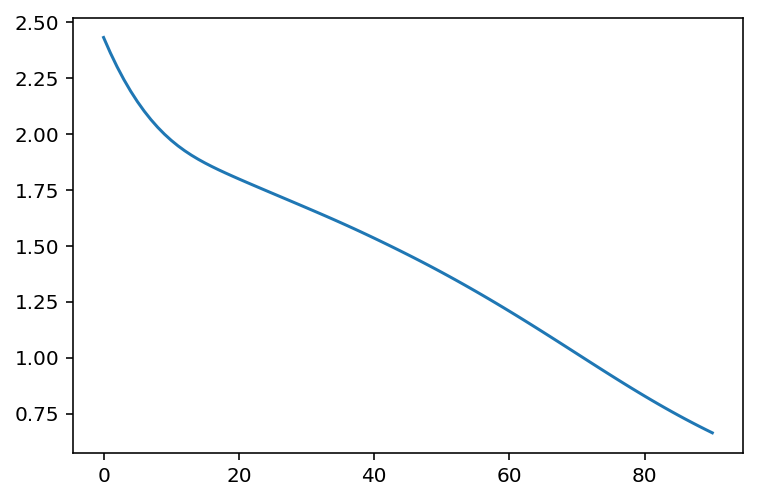

In [ ]:
N_EPOCHS = 5000
LR = 0.005
end_early = False
seq_i = ""

net.train() # Ensure net in training mode
for epoch_i in range(N_EPOCHS):
    # Zero out gradients
    optimizer.zero_grad()
    
    # Get net output, calculate loss, and generate gradients
    output = net(data.X)
    loss = criterion(output, data.y)
    loss.backward() # Generate gradients via autodiff
    
    # Step
    # -----------------------------------
    # Clip params
    for param in net.parameters():
        if param.grad is None:
            continue
        grad_val = torch.clamp(param.grad, -5, 5)
    optimizer.step()
    # -----------------------------------
    
    # Track loss
    losses.append(loss.item())
    
    # Qualitative Eval
    if epoch_i % 10 == 0:
        seq_i = net.generate(data, data.string[0], num_steps=len(data.string))
        
        if seq_i == data.string:
            end_early = True
            
    # Stdout
    # --------------------------------
    stdout_str = f'\rEpoch {epoch_i+1}/{N_EPOCHS} -- Loss: {losses[-1]:0.4f} -- Network out: {seq_i}'
    sys.stdout.write(stdout_str)
    sys.stdout.flush()
    # --------------------------------
    
    if end_early:
        print(f"\nEnding early. Converged in {epoch_i} epochs.")
        break
    
plt.plot(losses)

# Generate Text

In [ ]:
init_char = data.string[0]
net.generate(data, init_char, num_steps=len(data.string))

'Hello, RNN!'